# 01 — Качество данных

Цель: проверить полноту, дубликаты, выбросы и временное покрытие панельного датасета
`panel.csv` перед построением моделей.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from pathlib import Path

# Стиль графиков
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

# Директория для сохранения фигур
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("..") / "data" / "panel.csv"
print(f"FIG_DIR : {FIG_DIR.resolve()}")
print(f"DATA_PATH: {DATA_PATH.resolve()}")


FIG_DIR : /repo/notebooks/figures
DATA_PATH: /repo/data/panel.csv


## 2. Загрузка данных

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"Shape: {df.shape}")
print(f"Период: {df['date'].min().date()} .. {df['date'].max().date()}")
print(f"Уникальных облигаций (ISIN): {df['isin'].nunique()}")
print()
print("Типы данных:")
print(df.dtypes.to_string())


Shape: (295569, 34)
Период: 2020-01-03 .. 2026-03-30
Уникальных облигаций (ISIN): 967

Типы данных:
date                  datetime64[us]
isin                             str
g_spread                     float64
duration                     float64
rating_numeric               float64
net_debt_ebitda              float64
ebitda_margin                float64
ebitda_yoy                   float64
revenue_yoy                  float64
debt_to_equity               float64
roe                          float64
roa                          float64
rsbu_net_debt                float64
rsbu_ebit                    float64
rsbu_interest_paid           float64
rsbu_icr                     float64
rsbu_total_assets            float64
rsbu_revenue                 float64
key_rate                     float64
ofz_slope                    float64
rvi                          float64
oil_brent                    float64
usdrub                       float64
sector                           str
issue_volume

In [3]:
df.head(3)


,date,isin,g_spread,duration,rating_numeric,net_debt_ebitda,ebitda_margin,ebitda_yoy,revenue_yoy,debt_to_equity,...,issue_volume_rub,imoex_return,volume_ma20,coupon_rate,age_days,imoex_realized_vol,time_to_maturity,coupon_frequency,is_state_owned,issuer_name
0,2020-01-03,RU000A0JSGV0,4.672847,0.501370,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000e+10,1.001356,565109.8,9.80,2723,NaN,4557.0,2,0,"""Российские ЖД"" ОАО 32 обл."
1,2020-01-03,RU000A0JSQ58,2.798600,0.071233,1.0,NaN,NaN,NaN,NaN,NaN,...,1.000000e+10,1.001356,200723.2,12.00,2704,NaN,2756.0,2,1,ФСК Россети(ПАО)-обл. сер.22
2,2020-01-03,RU000A0JWV63,3.899662,4.630137,3.0,NaN,NaN,NaN,NaN,NaN,...,5.000000e+09,1.001356,1096529.9,14.25,1185,NaN,NaN,2,0,"""Россельхозбанк"" (АО) обл.08Т1"


In [4]:
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T


,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
date,295569,2024-04-12 07:04:48.334703,2020-01-03 00:00:00,2020-03-13 00:00:00,2020-11-18 00:00:00,2023-04-11 00:00:00,2024-10-02 00:00:00,2025-09-02 00:00:00,2026-02-20 00:00:00,2026-03-23 00:00:00,2026-03-30 00:00:00,NaN
g_spread,295569.0,7.37794,-120.9746,-7.594148,0.136579,1.291989,2.866043,6.800263,17.903913,84.107632,986.9019,32.130419
duration,295569.0,1.787463,0.00274,0.024658,0.10137,0.843836,1.580822,2.427397,4.180822,6.309589,9.556164,1.317711
rating_numeric,245059.0,5.131491,1.0,1.0,1.0,2.0,4.0,7.0,13.0,15.0,16.0,3.722243
net_debt_ebitda,60227.0,2.257936,-7.62,-0.55,0.15,1.11,1.83,2.94,5.4,13.49,15.29,2.106513
ebitda_margin,67389.0,44.312441,-67.2,0.26,6.72,13.68,28.6,40.16,71.64,155.98,2136.87,171.675972
ebitda_yoy,56589.0,36.815894,-107.34,-98.47,-54.81,-0.11,22.03,48.55,160.62,414.9,957.04,93.724525
revenue_yoy,124505.0,43.466762,-93.24,-47.54,-17.61,5.29,13.97,27.84,69.97,204.19,11070.91,520.911506
debt_to_equity,134559.0,-212.316224,-16604.48,-14545.79,-34.26,0.73,1.89,4.39,12.77,19.22,322.13,1691.620819
roe,174346.0,14.049057,-182.26,-85.83,-42.56,0.97,14.3,26.28,57.08,100.72,451.87,35.346657


## 3. Анализ пропусков

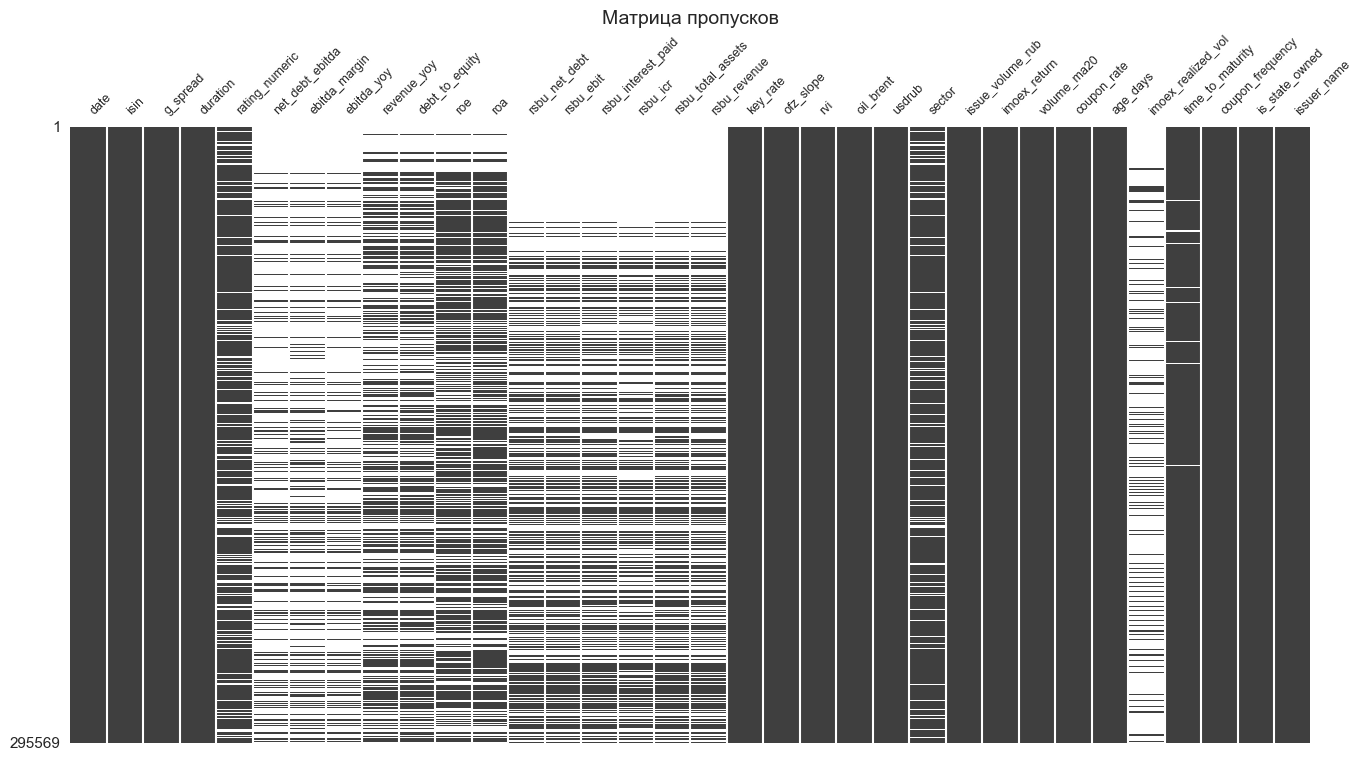

In [5]:
fig, ax = plt.subplots(figsize=(16, 8))
msno.matrix(df, ax=ax, sparkline=False, fontsize=9)
ax.set_title("Матрица пропусков", fontsize=14)
plt.savefig(FIG_DIR / "01_missingness_matrix.png", bbox_inches="tight", dpi=120)
plt.show()


In [6]:
nan_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nan_table = pd.DataFrame({
    "Пропусков": df.isna().sum().sort_values(ascending=False),
    "% пропусков": nan_pct.round(2),
})
nan_table[nan_table["% пропусков"] > 0]


,Пропусков,% пропусков
imoex_realized_vol,250190,84.65
ebitda_yoy,238980,80.85
net_debt_ebitda,235342,79.62
ebitda_margin,228180,77.20
rsbu_icr,189999,64.28
rsbu_revenue,180037,60.91
rsbu_interest_paid,178641,60.44
rsbu_ebit,174212,58.94
rsbu_total_assets,174212,58.94
rsbu_net_debt,174212,58.94


### Пропуски по месяцам для ключевых столбцов

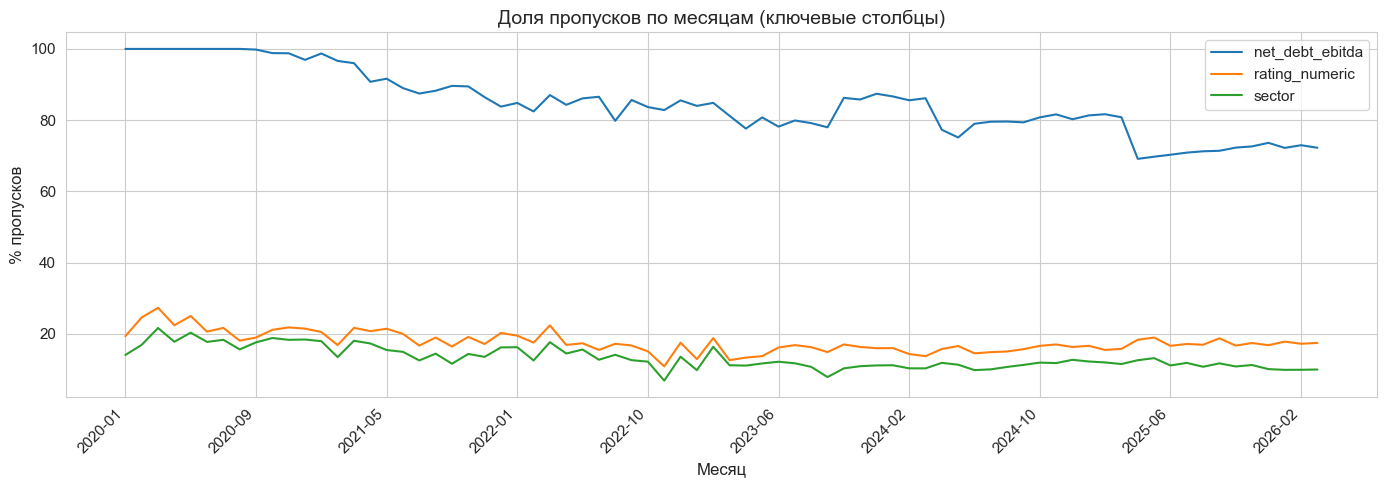

In [7]:
key_cols = ["net_debt_ebitda", "rating_numeric", "sector"]
df["ym"] = df["date"].dt.to_period("M")

monthly_nan = (
    df.groupby("ym")[key_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .reset_index()
)
monthly_nan["ym_str"] = monthly_nan["ym"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
for col in key_cols:
    ax.plot(monthly_nan["ym_str"], monthly_nan[col], label=col, linewidth=1.5)

ax.set_xlabel("Месяц")
ax.set_ylabel("% пропусков")
ax.set_title("Доля пропусков по месяцам (ключевые столбцы)")
ax.legend()
# показываем каждую 6-ю метку
ticks = ax.get_xticks()
labels = [item.get_text() for item in ax.get_xticklabels()]
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_missingness_over_time.png", bbox_inches="tight", dpi=120)
plt.show()


## 4. Проверка дубликатов

In [8]:
dup_count = df.duplicated(subset=["date", "isin"]).sum()
print(f"Дубликатов (date, isin): {dup_count}")
if dup_count > 0:
    print("Примеры дубликатов:")
    display(df[df.duplicated(subset=["date", "isin"], keep=False)].head(10))
else:
    print("Дубликатов нет — OK")


Дубликатов (date, isin): 0
Дубликатов нет — OK


## 5. Категориальные переменные

### 5.1 Сектор (sector)

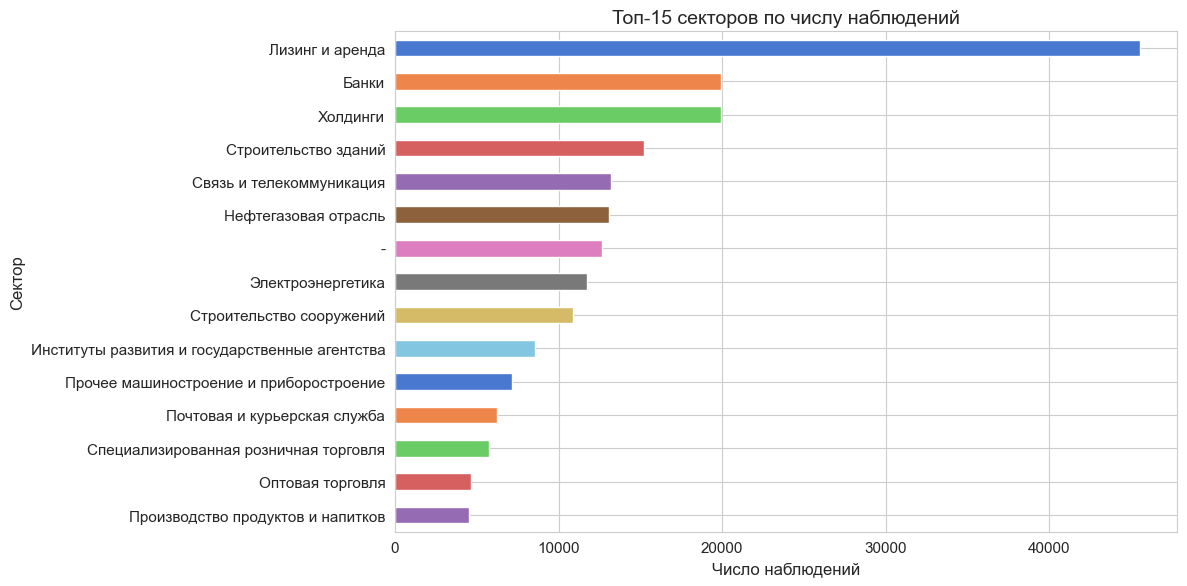

Всего уникальных секторов: 54
NaN в sector: 35526


In [9]:
sector_counts = df["sector"].value_counts()
top15 = sector_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top15.plot.barh(ax=ax, color=sns.color_palette("muted", len(top15)))
ax.set_xlabel("Число наблюдений")
ax.set_ylabel("Сектор")
ax.set_title("Топ-15 секторов по числу наблюдений")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_sector_top15.png", bbox_inches="tight", dpi=120)
plt.show()

print(f"Всего уникальных секторов: {df['sector'].nunique()}")
print(f"NaN в sector: {df['sector'].isna().sum()}")


### 5.2 Рейтинг (rating_numeric)

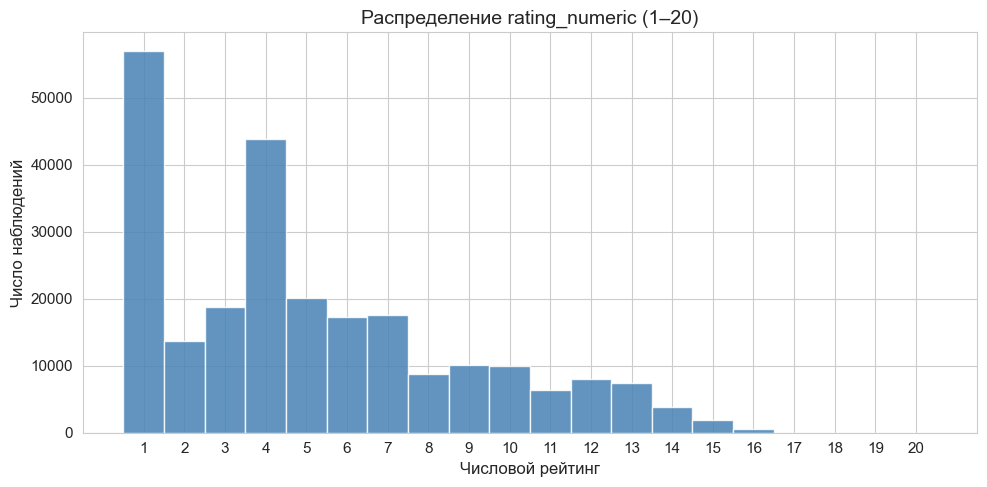

Мин: 1.0, Макс: 16.0, Медиана: 4.0
NaN: 50510 (17.1%)


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
rating_data = df["rating_numeric"].dropna()
bins = np.arange(0.5, 21.5, 1)
ax.hist(rating_data, bins=bins, edgecolor="white", color="steelblue", alpha=0.85)
ax.set_xlabel("Числовой рейтинг")
ax.set_ylabel("Число наблюдений")
ax.set_title("Распределение rating_numeric (1–20)")
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rating_distribution.png", bbox_inches="tight", dpi=120)
plt.show()

print(f"Мин: {rating_data.min()}, Макс: {rating_data.max()}, Медиана: {rating_data.median()}")
print(f"NaN: {df['rating_numeric'].isna().sum()} ({df['rating_numeric'].isna().mean()*100:.1f}%)")


### 5.3 Государственное участие (is_state_owned)

In [11]:
state_counts = df["is_state_owned"].value_counts(dropna=False)
print("Распределение is_state_owned:")
print(state_counts)
print(f"\nДоля гос. облигаций: {state_counts.get(1, state_counts.get(True, 0)) / len(df) * 100:.1f}%")


Распределение is_state_owned:
is_state_owned
0    231345
1     64224
Name: count, dtype: int64

Доля гос. облигаций: 21.7%


## 6. Выбросы — числовые признаки

### 6.1 g_spread — целевая переменная

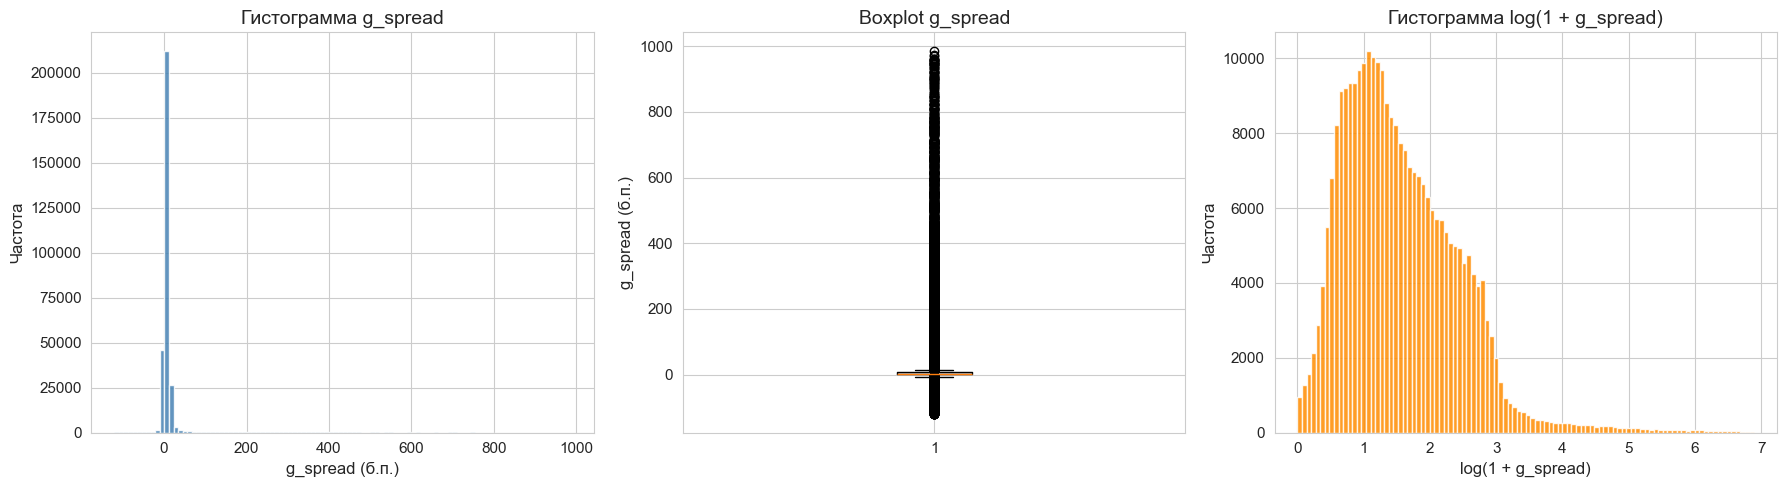

Квантили g_spread:
    1.0%:     -7.6 б.п.
    5.0%:      0.1 б.п.
   25.0%:      1.3 б.п.
   50.0%:      2.9 б.п.
   75.0%:      6.8 б.п.
   95.0%:     17.9 б.п.
   99.0%:     84.1 б.п.

Мин: -121.0, Макс: 986.9, Среднее: 7.4, Std: 32.1


In [12]:
gs = df["g_spread"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(gs, bins=100, edgecolor="white", color="steelblue", alpha=0.85)
axes[0].set_xlabel("g_spread (б.п.)")
axes[0].set_ylabel("Частота")
axes[0].set_title("Гистограмма g_spread")

# Boxplot
axes[1].boxplot(gs, vert=True)
axes[1].set_ylabel("g_spread (б.п.)")
axes[1].set_title("Boxplot g_spread")

# Логарифмическая гистограмма (для положительных значений)
gs_pos = gs[gs > 0]
axes[2].hist(np.log1p(gs_pos), bins=100, edgecolor="white", color="darkorange", alpha=0.85)
axes[2].set_xlabel("log(1 + g_spread)")
axes[2].set_ylabel("Частота")
axes[2].set_title("Гистограмма log(1 + g_spread)")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_gspread_distribution.png", bbox_inches="tight", dpi=120)
plt.show()

print("Квантили g_spread:")
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
for q in quantiles:
    print(f"  {q*100:5.1f}%: {gs.quantile(q):8.1f} б.п.")

print(f"\nМин: {gs.min():.1f}, Макс: {gs.max():.1f}, Среднее: {gs.mean():.1f}, Std: {gs.std():.1f}")


### 6.2 Boxplot'ы для net_debt_ebitda, rsbu_icr, roe, roa

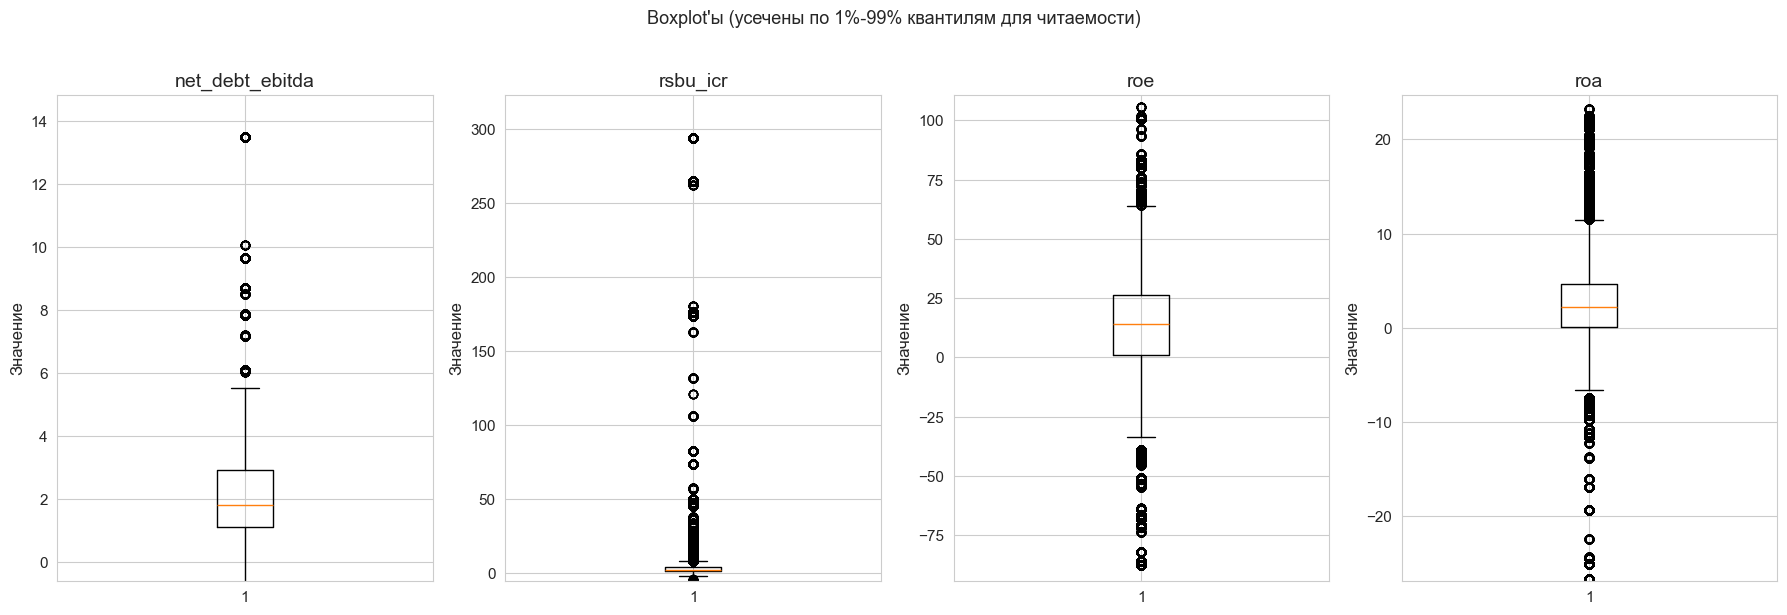

Крайние значения:
  net_debt_ebitda     : мин=       -7.62, макс=       15.29, 1%=     -0.55, 99%=     13.49
  rsbu_icr            : мин=     -158.67, макс=    17273.97, 1%=     -5.06, 99%=    293.76
  roe                 : мин=     -182.26, макс=      451.87, 1%=    -85.83, 99%=    100.72
  roa                 : мин=      -42.78, макс=       50.73, 1%=    -24.50, 99%=     22.49


In [13]:
outlier_cols = ["net_debt_ebitda", "rsbu_icr", "roe", "roa"]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Значение")
    q01, q99 = data.quantile(0.01), data.quantile(0.99)
    axes[i].set_ylim(q01 - 0.1 * abs(q01), q99 + 0.1 * abs(q99))

plt.suptitle("Boxplot'ы (усечены по 1%-99% квантилям для читаемости)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_outliers_boxplots.png", bbox_inches="tight", dpi=120)
plt.show()

print("Крайние значения:")
for col in outlier_cols:
    data = df[col].dropna()
    print(f"  {col:20s}: мин={data.min():12.2f}, макс={data.max():12.2f}, "
          f"1%={data.quantile(0.01):10.2f}, 99%={data.quantile(0.99):10.2f}")


### 6.3 Подозрительные наблюдения: g_spread < -50 или > 100

In [14]:
suspicious = df[(df["g_spread"] < -50) | (df["g_spread"] > 100)].copy()
print(f"Подозрительных строк (g_spread < -50 или > 100): {len(suspicious)} из {len(df)} "
      f"({len(suspicious)/len(df)*100:.2f}%)")
print(f"Уникальных облигаций: {suspicious['isin'].nunique()}")
print()

if len(suspicious) > 0:
    # Распределение по типу
    neg = suspicious[suspicious["g_spread"] < -50]
    pos = suspicious[suspicious["g_spread"] > 100]
    print(f"  g_spread < -50: {len(neg)} строк, {neg['isin'].nunique()} облигаций")
    print(f"  g_spread > 100: {len(pos)} строк, {pos['isin'].nunique()} облигаций")
    print()
    print("Топ-10 облигаций по числу подозрительных наблюдений:")
    top_susp = (
        suspicious.groupby(["isin", "issuer_name"])
        .agg(n=("g_spread", "size"), mean_gs=("g_spread", "mean"))
        .sort_values("n", ascending=False)
        .head(10)
    )
    display(top_susp)


Подозрительных строк (g_spread < -50 или > 100): 3049 из 295569 (1.03%)
Уникальных облигаций: 161

  g_spread < -50: 505 строк, 60 облигаций
  g_spread > 100: 2544 строк, 128 облигаций

Топ-10 облигаций по числу подозрительных наблюдений:


,,n,mean_gs
isin,issuer_name,,
RU000A1008V9,РОСНАНО АО 08,193,238.814580
RU000A106K43,РЖД БО 001Р-26R,112,116.517359
RU000A106ZL5,РЖД БО 001P-28R,111,247.529877
RU000A108447,Росагролизинг 001P-05,111,336.776305
RU000A105UC7,ИА Титан-5 А,101,300.136724
RU000A108DE3,ГТЛК БО 001P-21,99,237.167214
RU000A107TT9,ГТЛК БО 002P-03,96,258.547284
RU000A109DV5,Интерлизинг 001Р-09,88,279.878274
RU000A0JXE06,ГосТранспортЛизингКомп 001P-03,86,262.182812


## 7. Временное покрытие

### 7.1 Уникальные облигации в торгах по месяцам

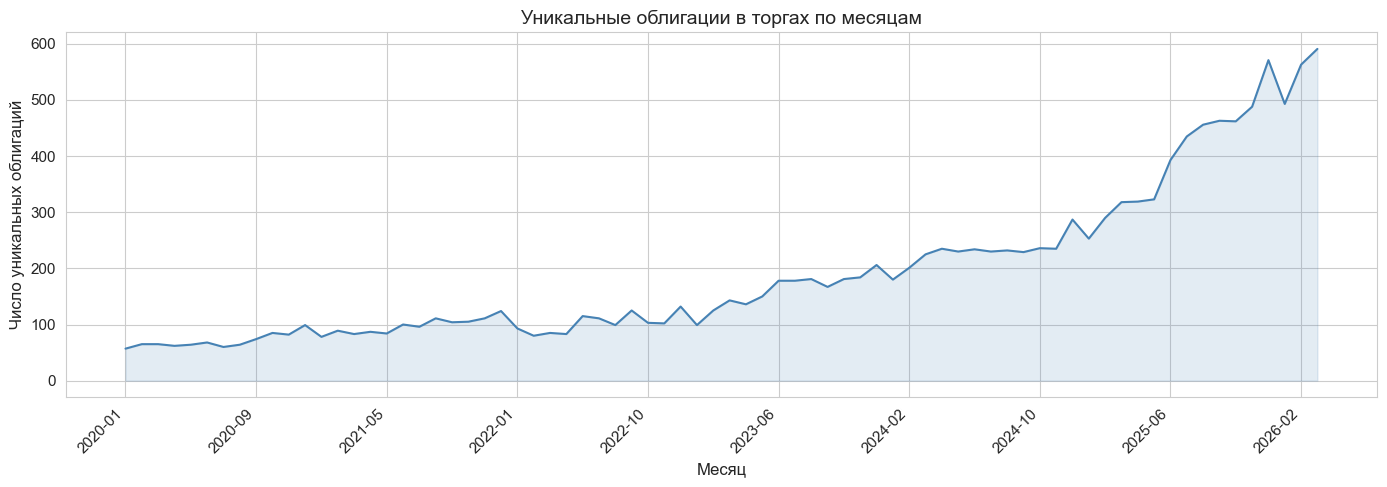

Мин. облигаций в месяц: 57
Макс. облигаций в месяц: 591
Медиана: 134


In [15]:
bonds_per_month = (
    df.groupby(df["date"].dt.to_period("M"))["isin"]
    .nunique()
    .reset_index()
)
bonds_per_month.columns = ["month", "n_bonds"]
bonds_per_month["month_str"] = bonds_per_month["month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bonds_per_month["month_str"], bonds_per_month["n_bonds"],
        color="steelblue", linewidth=1.5)
ax.fill_between(range(len(bonds_per_month)), bonds_per_month["n_bonds"],
                alpha=0.15, color="steelblue")
ax.set_xlabel("Месяц")
ax.set_ylabel("Число уникальных облигаций")
ax.set_title("Уникальные облигации в торгах по месяцам")
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_bonds_per_month.png", bbox_inches="tight", dpi=120)
plt.show()

print(f"Мин. облигаций в месяц: {bonds_per_month['n_bonds'].min()}")
print(f"Макс. облигаций в месяц: {bonds_per_month['n_bonds'].max()}")
print(f"Медиана: {bonds_per_month['n_bonds'].median():.0f}")


### 7.2 Новые выпуски по годам

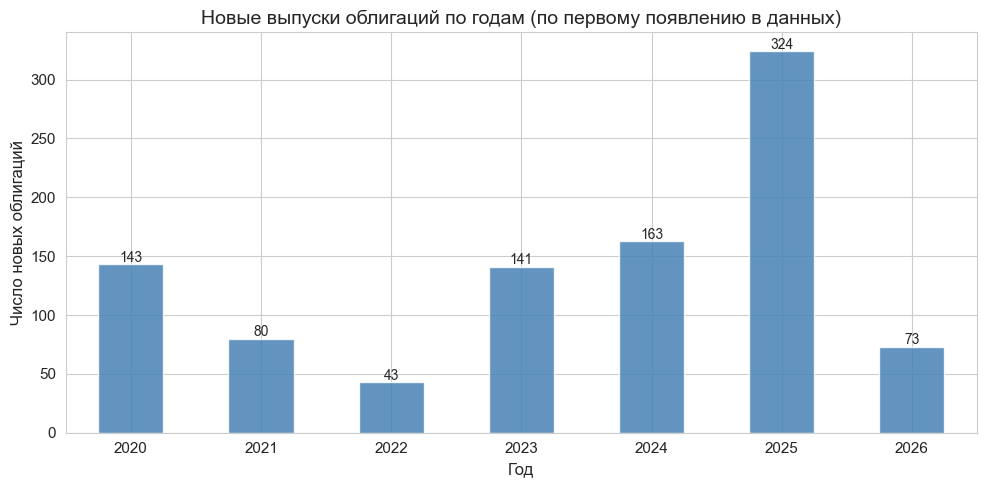

In [16]:
first_seen = df.groupby("isin")["date"].min().reset_index()
first_seen.columns = ["isin", "first_date"]
first_seen["year"] = first_seen["first_date"].dt.year

issues_by_year = first_seen["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
issues_by_year.plot.bar(ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Год")
ax.set_ylabel("Число новых облигаций")
ax.set_title("Новые выпуски облигаций по годам (по первому появлению в данных)")
for i, (yr, cnt) in enumerate(issues_by_year.items()):
    ax.text(i, cnt + 2, str(cnt), ha="center", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_new_issues_by_year.png", bbox_inches="tight", dpi=120)
plt.show()


## 8. Итоги проверки качества данных

**Размер:** `panel.csv` содержит ~295 тыс. строк, ~967 облигаций, 34 столбца, период 2020-01-03 .. 2026-03-30.

### Основные выводы

| Проверка | Результат |
|---|---|
| Дубликаты (date, isin) | *заполнить после запуска* |
| Пропуски | См. таблицу выше; ключевые столбцы — net_debt_ebitda, rating_numeric, sector |
| Выбросы g_spread | Экстремальные значения (< -50 или > 100) — предположительно дефолтные / неликвидные бумаги |
| Временное покрытие | Число облигаций в торгах варьируется; есть сезонность |
| Категориальные | Распределение секторов, рейтингов, is_state_owned проверено |

### Рекомендации для следующих шагов

1. **Фильтрация выбросов g_spread**: рассмотреть отсечение по 1–99% квантилям или маркировку дефолтных бумаг
2. **Импутация пропусков**: forward-fill для фундаментальных данных (они обновляются ежеквартально)
3. **Кодирование секторов**: top-N + "прочее"
4. **Валидация рейтингов**: проверить маппинг числового рейтинга к буквенным
5. Результаты скопировать в `eda_findings.md` после окончательного прогона
